In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from IPython.core.pylabtools import figsize
from sympy.benchmarks.bench_meijerint import alpha
from torch.utils.data import DataLoader
import random
from IPython.display import display
from ipycanvas import Canvas
from ipywidgets import Button, HBox, VBox, Output
from PIL import Image

# 检测
print("Python解释器路径：", sys.executable)
print("PyTorch版本：", torch.__version__)
print("CUDA(GPU加速)是否可用：", torch.cuda.is_available())

Python解释器路径： D:\Miniconda\envs\dl\python.exe
PyTorch版本： 2.5.1
CUDA(GPU加速)是否可用： True


【原始数据】
编号     身高(cm)   体重(kg)    标签
------------------------------------------------------------
  1      175        71         偏瘦
  2      160        63         偏胖
  3      172        69         偏瘦
  4      162        65         偏胖
  5      170        66         偏瘦
  6      164        67         偏胖
  7      168        64         偏瘦
  8      166        69         偏胖
  9      165        62         偏瘦
  10     168        72         偏胖

样本1:  身高=1.000, 体重=0.900, 标签=0
样本2:  身高=0.000, 体重=0.100, 标签=1
样本3:  身高=0.800, 体重=0.700, 标签=0
样本4:  身高=0.133, 体重=0.300, 标签=1
样本5:  身高=0.667, 体重=0.400, 标签=0
样本6:  身高=0.267, 体重=0.500, 标签=1
样本7:  身高=0.533, 体重=0.200, 标签=0
样本8:  身高=0.400, 体重=0.700, 标签=1
样本9:  身高=0.333, 体重=0.000, 标签=0
样本10: 身高=0.533, 体重=1.000, 标签=1

第1轮，第1个样本，更新权重: [-0.5  -0.45], 更新偏置: -0.5
第1轮，第2个样本，更新权重: [-0.5 -0.4], 更新偏置: 0.0
第1轮，第4个样本，更新权重: [-0.43333333 -0.25      ], 更新偏置: 0.5
第1轮，第5个样本，更新权重: [-0.76666667 -0.45      ], 更新偏置: 0.0
第1轮，第6个样本，更新权重: [-0.63333333 -0.2       ], 更新偏置: 0.5
第1轮，第7个样本，更

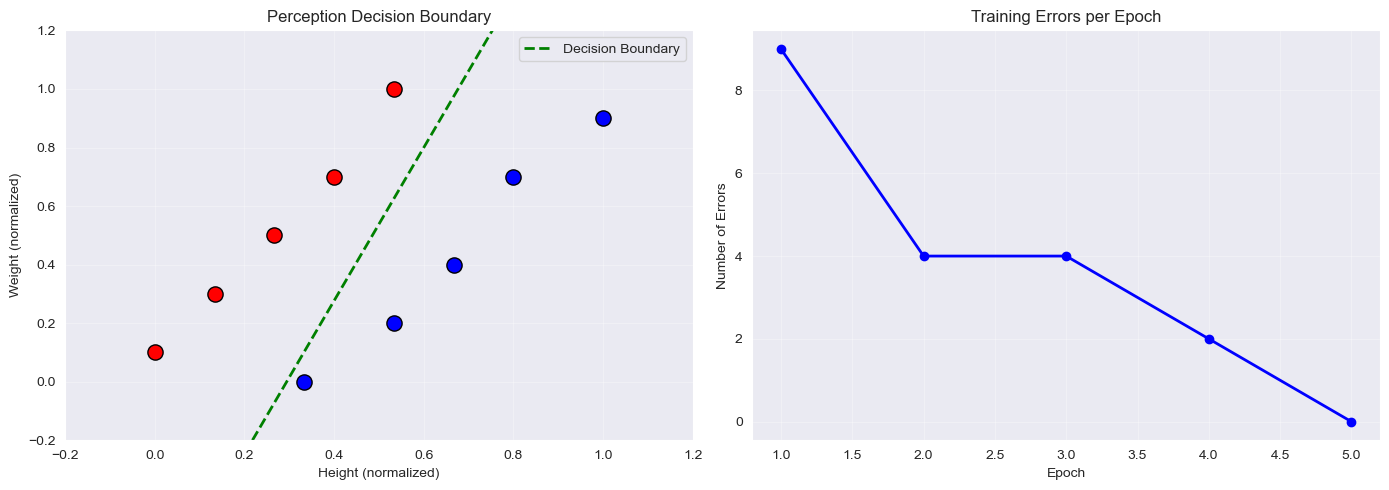

身高=168cm, 体重=48kg ==> 偏瘦
身高=162cm, 体重=82kg ==> 偏胖
身高=175cm, 体重=70kg ==> 偏瘦


In [6]:
'''单元1：感知机'''
# ========== 1.准备数据 ==========
raw_data = np.array([
    [175, 71], # 0
    [160, 63], # 1
    [172, 69], # 0
    [162, 65], # 1
    [170, 66], # 0
    [164, 67], # 1
    [168, 64], # 0
    [166, 69], # 1
    [165, 62], # 0
    [168, 72], # 1
])

labels = np.array([0, 1, 0, 1, 0, 1, 0, 1, 0, 1])

print("=" * 60)
print("【原始数据】")
print("=" * 60)
print(f"{'编号':<6} {'身高(cm)':<8} {'体重(kg)':<9} {'标签'}")
print("-" * 60)
for i in range(len(raw_data)):
    label_str = "偏胖" if labels[i] == 1 else "偏瘦"
    print(f"  {i+1:<6} {raw_data[i][0]:<10} {raw_data[i][1]:<10} {label_str}")
print("=" * 60)
print()

# ========== 2.数据归一化 ==========
"""
原始数据中身高的数值在160~170之间，而体重数值在45~85之间，两个特征的量级差距很大。如果直接把原始数据塞进感知机，身高对权重的影响会远远大于体重，导致学习过程不稳定。因此我们先对数据做一次归一化处理，把所有特征值统一压缩到0~1之间。
"""
# 计算每个特征的最小值和最大值
x_min = raw_data.min(axis=0) # [160, 45]
x_max = raw_data.max(axis=0) # [170, 85]

# Min-Max 归一化，把所有值压缩到 0~1
X = (raw_data - x_min) / (x_max - x_min)

# 打印归一化结果
for i in range(len(X)):
    if i < 9: print(f"样本{i+1}:  身高={X[i][0]:.3f}, 体重={X[i][1]:.3f}, 标签={labels[i]}")
    else: print(f"样本{i+1}: 身高={X[i][0]:.3f}, 体重={X[i][1]:.3f}, 标签={labels[i]}")
print()

# ========== 3.定义感知机 ==========
"""
__init__负责设定超参数，fit 是训练入口。权重初始化为 0，意味着感知机一开始对两个特征一无所知。每轮遍历所有样本，犯错就更新权重，没错就跳过。当某一轮的所有样本都预测正确时，训练结束。
"""
class Perception:
    def __init__(self, learning_rate=1.0, n_iterations=100):
        self.lr = learning_rate             # 学习率
        self.n_iterations = n_iterations    # 最大训练轮数
        self.weights = None                 # 权重 w
        self.bias = None                    # 偏置 b
        self.errors_per_epoch = []          # 记录每轮错误数

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # 权重和偏置全部初始化为 0
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.errors_per_epoch = []

        for epoch in range(self.n_iterations):
            errors = 0 # 本轮错误次数
            for idx in range(n_samples):
                x_i, y_true = X[idx], y[idx]

                # 1、计算加权和：z = w1·x1 + w2·x2 + b
                z = np.dot(self.weights, x_i) + self.bias

                # 2、激活判断：z >= 0 输出 1，否则输出 0
                y_pred = 1 if z >= 0 else 0

                # 3、计算误差
                error = y_true - y_pred

                # 4、如果预测错误，更新权重和偏置
                if error != 0:
                    self.weights += self.lr * error * x_i   # 更新权重
                    self.bias += self.lr * error            # 更新偏置
                    errors += 1                             # 错误计数
                    print(f"第{epoch+1}轮，第{idx+1}个样本，更新权重: {self.weights}, 更新偏置: {self.bias}")

            self.errors_per_epoch.append(errors)

            # 本轮无错误 ==> 收敛，训练结束
            if errors == 0:
                print(f"第{epoch+1}轮，错误数归零，训练结束！")
                break

        return self

    def predict(self, X):
        # 计算加权和：z = w1·x1 + w2·x2 + b
        z = np.dot(X, self.weights) + self.bias

        # 激活判断：z >= 0 输出 1，否则输出 0
        return np.where(z >= 0, 1, 0)

# ========== 4.开始训练 ==========
"""
创建感知机实例，学习率=0.5，最大训练 100 轮。调用 fit 开始训练，控制台会打印每一轮的权重变化过程。
"""
model = Perception(learning_rate=0.5, n_iterations=100)
model.fit(X, labels)
print()

# ========== 5.验证所有样本 ==========
predictions = model.predict(X)

for i in range(len(X)):
    true_label = "偏胖" if labels[i] else "偏瘦"
    pred_label = "偏胖" if predictions[i] else "偏瘦"
    status = "✅" if predictions[i] == labels[i] else "❎"
    print(f"样本{i+1}: 真实={true_label}, 预测={pred_label}  {status}")

print(f"\n最终参数: w1={model.weights[0]:.4f}, w2={model.weights[1]:.4f}, b={model.bias:.4f}")

# ========== 6.可视化决策边界与训练曲线 ==========
"""
经过若干轮训练后，感知机最终会收敛到一组合适的参数，能够正确区分所有样本。这条在二维平面上把“偏瘦”和“偏胖”分开的线，就是感知机找到的决策边界。
"""

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ----- 左图：数据点 + 决策边界 -----
ax1 = axes[0]

# 画数据点（蓝色=偏瘦，红色=偏胖）
for i in range(len(X)):
    color = 'blue' if labels[i] == 0 else 'red'
    ax1.scatter(X[i][0], X[i][1], color=color, s=120, edgecolors='black', zorder=5)

# 画决策边界直线：w1·x1 + w2·x2 + b = 0 ==> x2 = -(w1·x1 + b) / w2
w1, w2, b = model.weights[0], model.weights[1], model.bias
if w2 != 0:
    x1_line = np.linspace(-0.2, 1.2, 100)
    x2_line = -(w1 * x1_line + b) / w2
    ax1.plot(x1_line, x2_line, 'g--', linewidth=2, label = 'Decision Boundary')

ax1.set_xlabel('Height (normalized)')
ax1.set_ylabel('Weight (normalized)')
ax1.set_title('Perception Decision Boundary')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-0.2, 1.2)
ax1.set_ylim(-0.2, 1.2)

# ----- 右图：每轮错误数 -----
ax2 = axes[1]
ax2.plot(range(1, len(model.errors_per_epoch) + 1), model.errors_per_epoch, 'b-o', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Number of Errors')
ax2.set_title('Training Errors per Epoch')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ========== 7.用训练好的模型预测新样本 ==========
"""
训练好的模型就像一个“已经学会判断的老师傅”，你给它新的数据，它直接告诉你结果。注意新数据也要做同样的归一化，因为模型是在归一化后的数据上学到的权重，输入必须保持一致。
"""
# 新数据：同样需要归一化
new_data = np.array([
    [168, 48], # 看上去偏瘦
    [162, 82], # 看上去偏胖
    [175, 70], # 不太确定
])
new_data_norm = (new_data - x_min) / (x_max - x_min) # 归一化

# 预测
new_pred = model.predict(new_data_norm)

for i in range(len(new_data)):
    res = "偏胖" if new_pred[i] else "偏瘦"
    print(f"身高={new_data[i][0]}cm, 体重={new_data[i][1]}kg ==> {res}")

In [7]:
'''单元2：反向传播'''
"""
用 PyTorch 实现：自动微分的优雅
"""
# ========== 1.数据 ==========
x = torch.tensor([[1.0]])
t = torch.tensor([[0.0]])

# ========== 2.网络 ==========
model = nn.Sequential(
    nn.Linear(1, 1, bias=False),    # w1
    nn.ReLU(),
    nn.Linear(1, 1, bias=False),    # w2
    nn.ReLU(),
    nn.Linear(1, 1, bias=False),    # w3
)

# 初始化权重
with torch.no_grad():
    model[0].weight.fill_(2.0)
    model[2].weight.fill_(3.0)
    model[4].weight.fill_(-1.0)

# ========== 3.损失函数 + 随机梯度下降优化器 ==========
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# # ========== 4.训练 100 轮 ==========
for epoch in range(100):
    loss = criterion(model(x), t)   # 前向传播 + 计算损失
    optimizer.zero_grad()           # 清空上一轮残留的梯度
    loss.backward()                 # 反向传播，自动计算梯度
    optimizer.step()                # 梯度下降更新权重

    if epoch % 10 == 0:
        print(f"Epoch {epoch+1:3d} | 预测值：{model(x).item():7.4f} | 损失：{loss.item():.4f}")

Epoch   1 | 预测值：-1.2674 | 损失：36.0000
Epoch  11 | 预测值：-0.0084 | 损失：0.0002
Epoch  21 | 预测值：-0.0001 | 损失：0.0000
Epoch  31 | 预测值：-0.0000 | 损失：0.0000
Epoch  41 | 预测值：-0.0000 | 损失：0.0000
Epoch  51 | 预测值：-0.0000 | 损失：0.0000
Epoch  61 | 预测值：-0.0000 | 损失：0.0000
Epoch  71 | 预测值：-0.0000 | 损失：0.0000
Epoch  81 | 预测值：-0.0000 | 损失：0.0000
Epoch  91 | 预测值：-0.0000 | 损失：0.0000


In [8]:
'''单元3：损失函数'''
"""
用 PyTorch 实现 MSE, BCE, Softmax + CE
"""
# ========== 回归：MSE 均方误差 ==========
criterion_mse = nn.MSELoss()        # 默认 reduction='mean' 求平均
pred = torch.tensor([[2.5], [1.1]])
target = torch.tensor([[2.0], [1.0]])
loss_mse = criterion_mse(pred, target)
print(f"MSELoss: {loss_mse.item():.4f}")

# ========== 二分类：BCEWithLogitsLoss ==========
# logits：Sigmoid之前输出；target必须float，取值0或1
criterion_bce = nn.BCEWithLogitsLoss()
logits = torch.tensor([1.2, -0.5])   # 网络原始输出，不手动sigmoid
target_bce = torch.tensor([1, 0])    # 0/1标签
loss_bce = criterion_bce(logits, target_bce.float())
print(f"BCEWithLogitsLoss: {loss_bce.item():.4f}")

# ========== 多分类：CrossEntropyLoss 交叉熵 ==========
# logits: [N, num_classes]  不需要softmax
# target: 类别下标 LongTensor，形状[N]，不要one‑hot
criterion_ce = nn.CrossEntropyLoss()
# batch_size=2，3个类别
logits_cls = torch.tensor([[0.3, 2.1, -1.2], [1.5, 0.2, 0.1]])
target_ce = torch.tensor([1, 0]).long()   # 第1个样本类别1，第2个样本类别0
loss_ce = criterion_ce(logits_cls, target_ce)
print(f"CrossEntropyLoss: {loss_ce.item():.4f}")

MSELoss: 0.1300
BCEWithLogitsLoss: 0.3687
CrossEntropyLoss: 0.3011


In [9]:
'''单元4~11'''
"""
写一个能够识别手写数字的神经网络
"""
# 固定随机种子，让 DataLoader 的 shuffle、模型初始化都可复现
# 不固定的话，每次重跑训练曲线会略有差异，对比时容易混淆
torch.manual_seed(42)

# 设置中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 数据预处理：转 tensor + 归一化
# ToTensor：把 plt 图（uint8, 0-255）转为 float tensor，范围 [0, 1]，shape 由 (H, W, C) ==> (C, H, W)
# Normalize：减均值除标准差，让像素分布零均值、单位方差
# 0.1307 / 0.3081 是 MNIST 训练集像素的 均值 / 标准差（）业界写死的常数
# 为什么要这一步？后面归一化那边会细说，简单来说就是能让训练更稳、收敛更快
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

# 第一次跑会自动从网上下载到 ./data/，之后走本地缓存
train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# DataLoader 把数据集切成 batch
# 训练集 shuffle=True：每个 epoch 打乱顺序，避免模型记住数据出现的次序
# 测试集 shuffle=False：评估时顺序无所谓，关掉 shuffle 让结果可复现
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_set, batch_size=256, shuffle=False)

print(f"训练集：{len(train_set)} 张")
print(f"测试集：{len(test_set)} 张")
print(f"每张图：{train_set[0][0].shape}（通道数 × 高 × 宽）")

训练集：60000 张
测试集：10000 张
每张图：torch.Size([1, 28, 28])（通道数 × 高 × 宽）


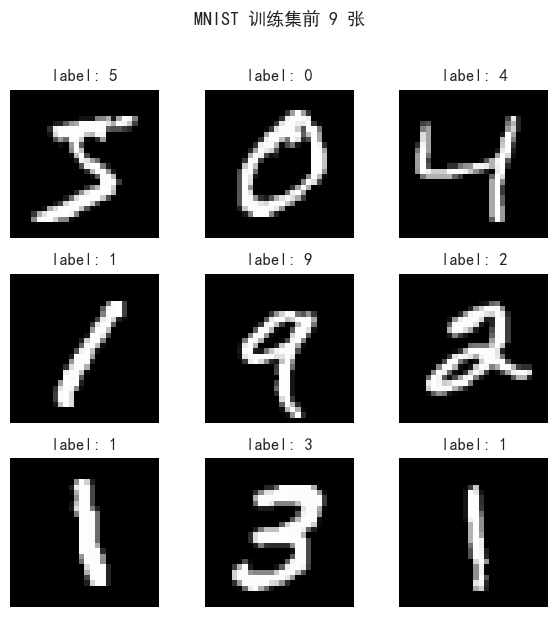

In [10]:
'''单元5'''
# 取 9 张样本看一下
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    img, label = train_set[i]
    # img 已经归一化过，反归一化回去显示（不然颜色不对）
    ax.imshow(img.squeeze() * 0.3081 + 0.1307, cmap='gray')
    ax.set_title(f"label: {label}", fontsize=12)
    ax.axis('off')
plt.suptitle("MNIST 训练集前 9 张", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [11]:
'''单元6'''
# 手动初始化 4 个参数张量：W1, b1, W2, b2
torch.manual_seed(42) # 单独重跑这一段时，再固定一次种子，让权重初始化可复现

# requires_grad=True: 告诉 autograd 这个张量是参数。需要记录梯度
# 没有这个标记，loss.backward() 算不出 p.grad
#
# (2.0 / n_in) ** 0.5 是 He 初始化的标准差，专门给 ReLU 网络用
# 经验值，先用着；为什么是 sqrt(2/n_in)，参数初始化那节再讲
W1 = (torch.randn(784, 128) * (2.0 / 784) ** 0.5).requires_grad_()
b1 = torch.zeros(128, requires_grad=True)

# 第二层：128 ==> 10（输出 10 个类别的 logits）
W2 = (torch.randn(128, 10) * (2.0 / 128) ** 0.5).requires_grad_()
b2 = torch.zeros(10, requires_grad=True)

# 把 4 个参数放一个列表里，后面统一更新
params = [W1, b1, W2, b2]
lr = 0.1 # 学习率：每次梯度下降迈多大一步。先拍 0.1，学习率与调度那节再细聊

print(f"网络共 {sum(p.numel() for p in params):,} 个参数")

网络共 101,770 个参数


In [12]:
'''单元7'''
# 训练 5 个 epoch
# 一个 epoch = 把整个训练集（60,000 张）完整过一遍
# 一个 batch = 128 张 （DataLoader 切的），所以一个 epoch 大约 469 个 batch
train_losses = []
test_accs = []

for epoch in range(5):
    running_loss = 0.0  # 累积本 epoch 所有 batch 的 loss × 样本数，最后求平均
    n_samples = 0

    for xb, yb in train_loader:
        # xb 形状 (128, 1, 28, 28), yb 形状 (128,)
        # 我们的网络只识别 1D 向量，所以把图像拍平成 (128, 784)
        x = xb.view(-1, 784)

        # ----- 1.forward: 线性 + 非线性 的组合 -----
        h = F.relu(x @ W1 + b1) # 隐藏层：内层线性变换，然后使用非线性函数 ReLU 激活
        logits = h @ W2 + b2 # 输出层：只做线性变换，不加 softmax(CrossEntropy 内部会做 log_softmax，自己加反而数值不稳)

        # ----- 2.loss: 算预测和真值的差距 -----
        # cross_entropy 接收 logits（未归一化的分数）和整数标签，自动做 softmax + 交叉熵
        loss = F.cross_entropy(logits, yb)

        # ----- 3.backward: 反向传播 -----
        # autograd 顺着前向那条计算图，从 loss 一路链式求导回每个 requires_grad 的张量
        # 求出来的梯度自动累加到 p.grad（所以下面要记得清零）
        loss.backward()

        # ----- 4.step: 梯度下降，沿梯度反方向更新参数 -----
        with torch.no_grad():       # 参数更新不需要建图
            for p in params:
                p -= lr * p.grad    # 沿梯度反方向迈 lr 这么大一步
                p.grad.zero_()      # 清零，防止下个 batch 的梯度叠加进来

        running_loss += loss.item() * yb.size(0)
        n_samples += yb.size(0)

    train_loss = running_loss / n_samples # 整个 epoch 的平均 loss

    # ----- 评估：测试集上跑一遍前向，统计准确率（不算梯度，更快更省内存）-----
    correct = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            x = xb.view(-1, 784)
            logits = F.relu(x @ W1 + b1) @ W2 + b2
            correct += (logits.argmax(1) == yb).sum().item()

    test_acc = correct / len(test_set) # 准确率

    train_losses.append(train_loss)
    test_accs.append(test_acc)
    print(f"epoch {epoch+1}/5 train_loss={train_loss:.4f} test_acc={test_acc:.4f}")

epoch 1/5 train_loss=0.2839 test_acc=0.9488
epoch 2/5 train_loss=0.1387 test_acc=0.9651
epoch 3/5 train_loss=0.1011 test_acc=0.9674
epoch 4/5 train_loss=0.0806 test_acc=0.9714
epoch 5/5 train_loss=0.0670 test_acc=0.9742


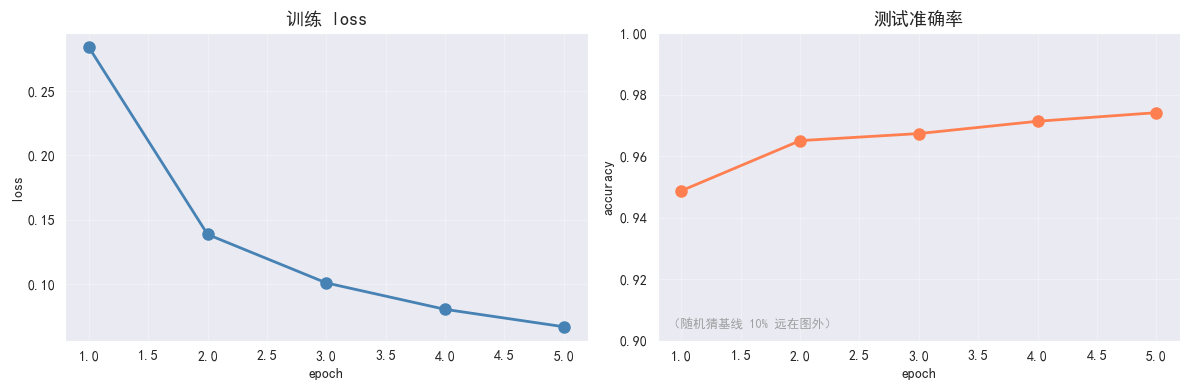

In [13]:
'''单元8'''
# 画训练曲线
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, len(train_losses)+1)

# 左：训练 loss——应该是单调下降的
axes[0].plot(epochs, train_losses, '-o', color='steelblue', lw=2, markersize=8)
axes[0].set_title("训练 loss", fontsize=13)
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].grid(alpha=0.3)

# 右：测试准确率——应该单调上升
# 实际值都在 0.94 以上，把 y 轴从 0.9 起画曲线变化更清楚
# （随机猜的基线是 0.10，远远低于此图范围，用文字标准一下即可）
axes[1].plot(epochs, test_accs, '-o', color='coral', lw=2, markersize=8)
axes[1].set_title("测试准确率", fontsize=13)
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')
axes[1].set_ylim(0.9, 1.0)
axes[1].annotate("（随机猜基线 10% 远在图外）", xy=(0.02, 0.04), xycoords='axes fraction', fontsize=9, color='gray', alpha=0.7)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
'''单元9'''
class SimpleMLP(nn.Module):
    """
    两层 MLP：784 ==> 128 ==> 10
    继承 nn.Module 之后，PyTorch 自动管理：
    - 把 self.fcN 里的参数收集起来（module.parameters()）
    - .train() / .eval() 自动切换 Dropout、BN 等层的行为
    - .to(device) 把所有参数搬到 GPU
    """
    def __init__(self):
        super().__init__()
        # nn.Linear(in, out)：一行同时帮我们造好 W (out × in) 和 b (out)
        # 默认初始化是 Kaiming uniform：和上面手写的 He normal 不完全一样，但都是给 ReLU 用的
        self.fc1 = nn.Linear(784, 128)  # 等价于手写版 W1, b1
        self.fc2 = nn.Linear(128, 10)   # 等价于手写版 W2, b2

    def forward(self, x):
        x = x.view(-1, 784)     # 拍平成 (batch, 748)
        x = F.relu(self.fc1(x)) # 隐层 + ReLU
        return self.fc2(x)      # 输出 logits（不如 softmax，原因同上）

torch.manual_seed(42)
model = SimpleMLP()
optimizer = optim.SGD(model.parameters(), lr=0.1) # SGD 内部就是手写版的 p -= lr * p.grad
loss_fn = nn.CrossEntropyLoss()                   # 等价于 F.cross_entropy

train_losses_v2 = []
test_accs_v2 = []

for epoch in range(5):
    model.train() # 进入“训练模式”（Dropout/BN 行为切换；这里没用到，但养成习惯）
    running_loss = 0.0
    n_samples = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()       # 替代手写版的 p.grad.zero_()，一行清掉所有参数的替代
        logits = model(xb)          # 1.forward，等价于 model.forward(xb)
        loss = loss_fn(logits, yb)  # 2.loss
        loss.backward()             # 3.backward，还是 autograd 在做事
        optimizer.step()            # 4.step，替代手写版的 p -= lr * p.grad
        running_loss += loss.item() * yb.size(0)
        n_samples += yb.size(0)

    model.eval() # 进入“评估模式”
    correct = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            correct += (model(xb).argmax(1) == yb).sum().item()

    train_losses_v2.append(running_loss / n_samples)
    test_accs_v2.append(correct / len(test_set))
    print(f"epoch {epoch+1}/5 train_loss={train_losses_v2[-1]:.4f} test_acc={test_accs_v2[-1]:.4f}")

epoch 1/5 train_loss=0.3329 test_acc=0.9466
epoch 2/5 train_loss=0.1606 test_acc=0.9626
epoch 3/5 train_loss=0.1147 test_acc=0.9674
epoch 4/5 train_loss=0.0915 test_acc=0.9726
epoch 5/5 train_loss=0.0738 test_acc=0.9748


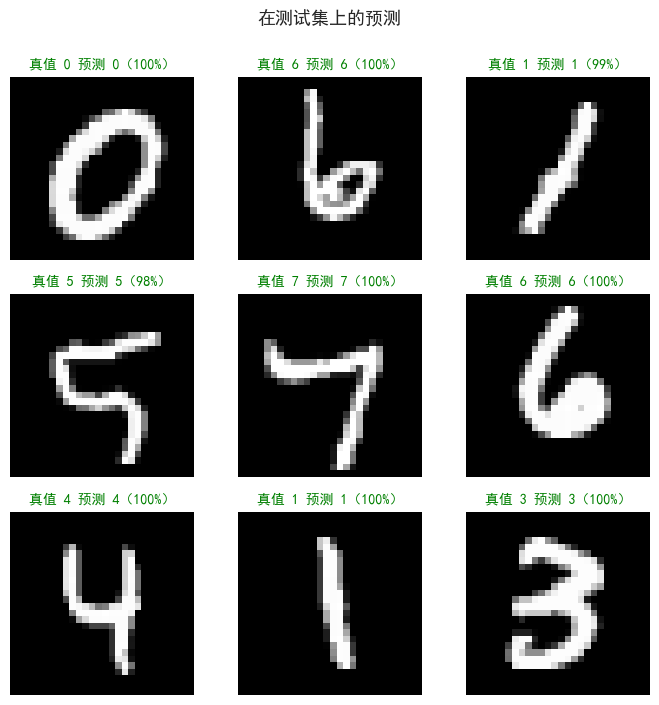

In [15]:
'''单元10'''
# 随机抽取 9 张测试图
random.seed(7)
indices = random.sample(range(len(test_set)), 9)

model.eval() # 推理模式
fig, axes = plt.subplots(3, 3, figsize=(7, 7))
with torch.no_grad(): # 推理时关闭替代，省内存、加速
    for ax, idx in zip(axes.flat, indices):
        img, label = test_set[idx]
        # img 形状 (1, 28, 28)，模型期望 (batch, 1, 28, 28)，所以 unsqueeze(0) 添一维
        logits = model(img.unsqueeze(0))
        # softmax 把 logits 变成概率分布；[0] 是因为 batch=1
        probs = F.softmax(logits, dim=1)[0]
        pred = int(probs.argmax())  # 概率最大的那个类
        conf = float(probs[pred])   # 模型对自己预测的“信心”

        # 反归一化回原始像素范围再显示，不如颜色会偏（前面 transform 里减过均值）
        ax.imshow(img.squeeze() * 0.3081 + 0.1307, cmap='gray')
        ok = (pred == label)
        ax.set_title(f"真值 {label} 预测 {pred}（{conf:.0%}）", fontsize=10, color=('green' if ok else 'red'))
        ax.axis('off')

plt.suptitle("在测试集上的预测", fontsize=13, y=1.00)
plt.tight_layout()
plt.show()

In [80]:
'''单元11'''
"""
画板 demo：让模型识别你画的数字 [0-9]
"""
assert 'model' in locals(), "❌请先运行训练代码，model变量需要存在"
device = torch.device("cpu")
model = model.to(device)
model.eval()

# =========改成你的图片路径=========
pil_img = Image.open("DL.ipynbCell11Images/3.png").convert("L")

img_raw = np.array(pil_img)
# 黑白翻转：黑笔迹→白，白底→黑底
img_raw = 255 - img_raw

# 找到所有笔迹（白色像素）
nonzero = np.argwhere(img_raw > 127)
if len(nonzero) == 0:
    print("图片空白，没有笔迹")
else:
    y_min, x_min = nonzero.min(axis=0)
    y_max, x_max = nonzero.max(axis=0)
    # 裁剪笔迹区域
    crop_region = img_raw[y_min:y_max, x_min:x_max]
    h, w = crop_region.shape
    # 【重点】缩放到最大20像素，四周留边，不要占满28
max_side = 20
scale = min(max_side / h, max_side / w)
new_h = int(h * scale)
new_w = int(w * scale)

crop_pil = Image.fromarray(crop_region)
resized_digit = crop_pil.resize((new_w, new_h), Image.Resampling.LANCZOS)

# 创建28×28全黑画布，把数字贴中间
canvas = np.zeros((28, 28), dtype=np.uint8)
paste_x = (28 - new_w) // 2
paste_y = (28 - new_h) // 2
canvas[paste_y:paste_y+new_h, paste_x:paste_x+new_w] = np.array(resized_digit)

# 转float、二值降噪
arr = canvas.astype(np.float32)/255.0
arr[arr > 0.35] = 1.0
arr[arr <= 0.35] = 0.0

# MNIST标准归一化
tensor_in = torch.from_numpy(arr).unsqueeze(0).unsqueeze(0)
tensor_in = (tensor_in - 0.1307) / 0.3081

with torch.no_grad():
    logits = model(tensor_in.to(device))
    prob_all = torch.softmax(logits, dim=1)[0].cpu().numpy()
    pred = int(np.argmax(prob_all))
    conf = prob_all[pred]

print("====推理结果====")
print(f"预测：{pred}，置信度：{conf:.2%}")
for idx, p in enumerate(prob_all):
    print(f"{idx}: {p:.2%}")

plt.figure(figsize=(3,3))
plt.imshow(arr, cmap="gray")
plt.title("送入网络的28×28图像")
plt.axis("off")
plt.show()

====推理结果====
预测：3，置信度：100.00%
0: 0.00%
1: 0.00%
2: 0.00%
3: 100.00%
4: 0.00%
5: 0.00%
6: 0.00%
7: 0.00%
8: 0.00%
9: 0.00%


<IPython.core.display.Javascript object>

In [ ]:
'''单元12'''